In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
# load spmi.csv into pandas dataframe with header as first row
spmi = pd.read_csv('data/racetrack2_T1/spmi.csv', header=0, sep=';')
spmi.head()

,# iterations,evaluations,p_advantages,m_advantages,p_dist_sup,p_dist_mean,m_dist_sup,m_dist_mean,alfa,beta,...,m_change,bound,w_current[0],w_current[1],w_current[2],w_current[3],w_target[0],w_target[1],w_target[2],w_target[3]
0,0.0,0.045762,0.039368,0.000099,2.000000,1.452933,0.8,0.112017,0.001505,0.0,...,1.0,0.000030,0.5,0.5,0.0,0.0,1.0,0.0,0.0,0.0
1,1.0,0.046276,0.039506,0.000092,2.000000,1.417511,0.8,0.111982,0.001548,0.0,...,1.0,0.000031,0.5,0.5,0.0,0.0,1.0,0.0,0.0,0.0
2,2.0,0.046796,0.039647,0.000084,1.996903,1.415142,0.8,0.111947,0.001559,0.0,...,1.0,0.000031,0.5,0.5,0.0,0.0,1.0,0.0,0.0,0.0
3,3.0,0.047322,0.039787,0.000076,1.993790,1.412757,0.8,0.111911,0.001569,0.0,...,1.0,0.000031,0.5,0.5,0.0,0.0,1.0,0.0,0.0,0.0
4,4.0,0.047853,0.039926,0.000068,1.990661,1.410357,0.8,0.111875,0.001580,0.0,...,1.0,0.000032,0.5,0.5,0.0,0.0,1.0,0.0,0.0,0.0


In [19]:
# load spmi.csv into pandas dataframe with header as first row
spmi_gp = pd.read_csv('data/racetrack2_gp_T1/spmi.csv', header=0, sep=';')
spmi_gp.head()

,# iterations,evaluations,p_advantages,m_advantages,p_dist_sup,p_dist_mean,m_dist_sup,m_dist_mean,alfa,beta,p_change,m_change,bound
0,0.0,0.045762,0.039368,9.270270e-19,2.000000,1.452933,2.775558e-16,1.136648e-17,0.001505,0.0,1.0,1.0,0.000030
1,1.0,0.046276,0.039506,9.356850e-19,2.000000,1.417511,2.775558e-16,1.138393e-17,0.001548,0.0,0.0,1.0,0.000031
2,2.0,0.046783,0.039647,9.446053e-19,1.999226,1.447977,2.775558e-16,1.140161e-17,0.001522,0.0,0.0,1.0,0.000030
3,3.0,0.047303,0.039784,9.533862e-19,1.998173,1.427633,2.775558e-16,1.141872e-17,0.001550,0.0,0.0,1.0,0.000031
4,4.0,0.047818,0.039921,9.623416e-19,1.997968,1.449268,2.775558e-16,1.143588e-17,0.001532,0.0,0.0,1.0,0.000031


In [20]:
models_dict = {
    'SPMI (Racetrack2)': spmi,
    'SPMI GP (Racetrack2)': spmi_gp
}

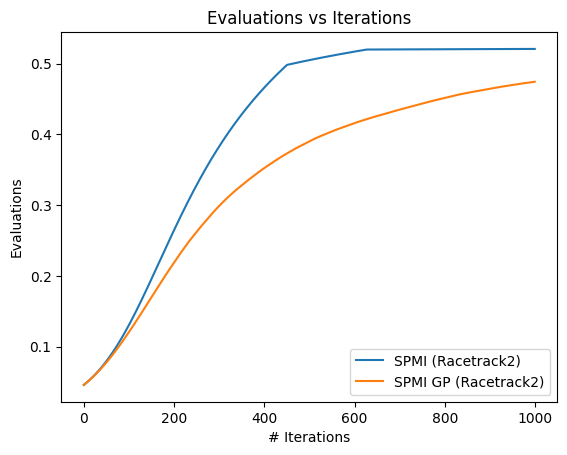

In [21]:
# plot "evaluations" against "# iterations" from the dataframe
def plot_evaluations_vs_iterations(models_dict):
    for model_name, model in models_dict.items():
        plt.plot(model['# iterations'], model['evaluations'], linestyle='-', label=model_name)
    plt.xlabel('# Iterations')
    plt.ylabel('Evaluations')
    plt.title('Evaluations vs Iterations')
    plt.legend()
    plt.show()

plot_evaluations_vs_iterations(models_dict)

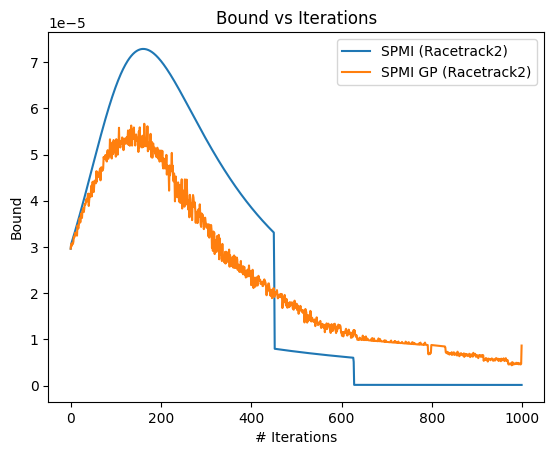

In [22]:

def plot_bound_vs_iterations(models_dict):
    for model_name, model in models_dict.items():
        plt.plot(model['# iterations'], model['bound'], linestyle='-', label=model_name)
    plt.xlabel('# Iterations')
    plt.ylabel('Bound')
    plt.title('Bound vs Iterations')
    plt.legend()
    plt.show()
plot_bound_vs_iterations(models_dict)

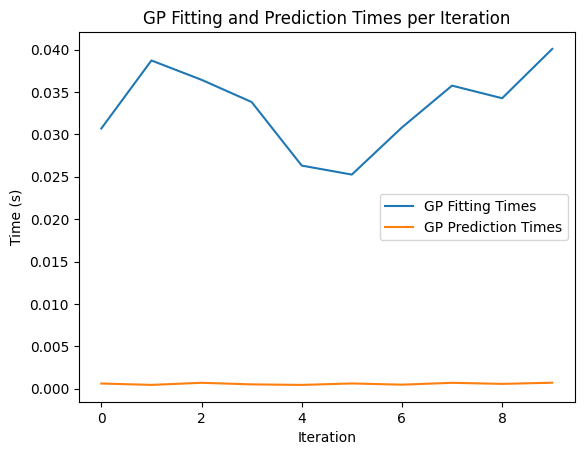

In [23]:
# load fitting and prediction times from csv files
gp_fitting_times = pd.read_csv('data/racetrack_gp_T1_gp_fitting_times.csv', header=None, sep=';')
gp_prediction_times = pd.read_csv('data/racetrack_gp_T1_gp_prediction_times.csv', header=None, sep=';')

# plot fitting and prediction times
plt.plot(gp_fitting_times.index, gp_fitting_times[0], label='GP Fitting Times')
plt.plot(gp_prediction_times.index, gp_prediction_times[0], label='GP Prediction Times')
plt.xlabel('Iteration')
plt.ylabel('Time (s)')
plt.title('GP Fitting and Prediction Times per Iteration')
plt.legend()
plt.show()

In [7]:
import math
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_metrics(file_input_dict, title = None):
    labels = list(file_input_dict.keys())
    file_paths = list(file_input_dict.values())

    dfs = [pd.read_csv(fp, header=0, sep=';') for fp in file_paths]

    metrics = [
        "state_coverage",
        "state_entropy",
        "reward_mean",
        "reward_std",
        "novelty_yield",
        "model_tv_mean",
        "model_tv_max"
    ]
    titles = {
        "state_coverage": "State Coverage",
        "state_entropy":  "State Entropy",
        "reward_mean":    "Reward Mean",
        "reward_std":     "Reward Std",
        "novelty_yield":  "Novelty Yield",
        "model_tv_mean":  "Model TV (mean)",
        "model_tv_max":   "Model TV (max)"
    }

    metrics = [m for m in metrics if all(m in df.columns for df in dfs)]

    if not metrics:
        raise ValueError("No known metrics found in provided files.")

    n_metrics = len(metrics)
    n_cols = 3
    n_rows = math.ceil(n_metrics / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharex=False)
    if title:
        fig.suptitle(title)

    axes_flat = axes.flatten() if isinstance(axes, (list, np.ndarray)) else [axes]

    for i, col in enumerate(metrics):
        ax = axes_flat[i]
        for df, label in zip(dfs, labels):
            ax.plot(df["iteration"], df[col], label=label)
        ax.set_title(titles.get(col, col))
        ax.set_xlabel("iteration")
        ax.grid(True)
        ax.legend()

    # hide any unused axes
    for j in range(len(metrics), len(axes_flat)):
        axes_flat[j].axis("off")

    plt.tight_layout()
    plt.show()


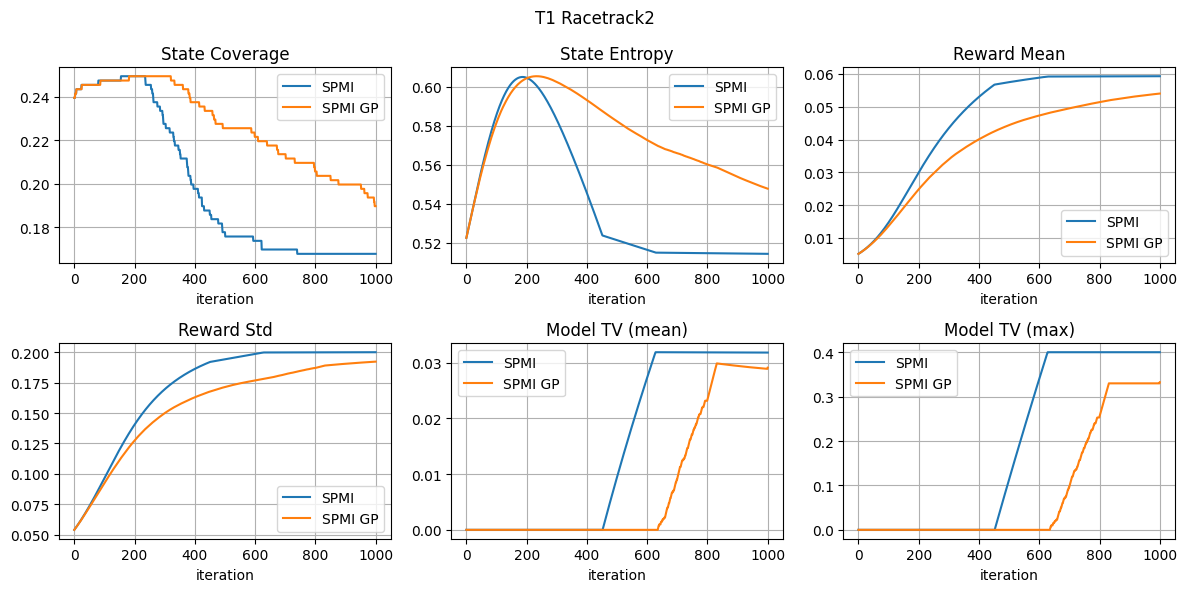

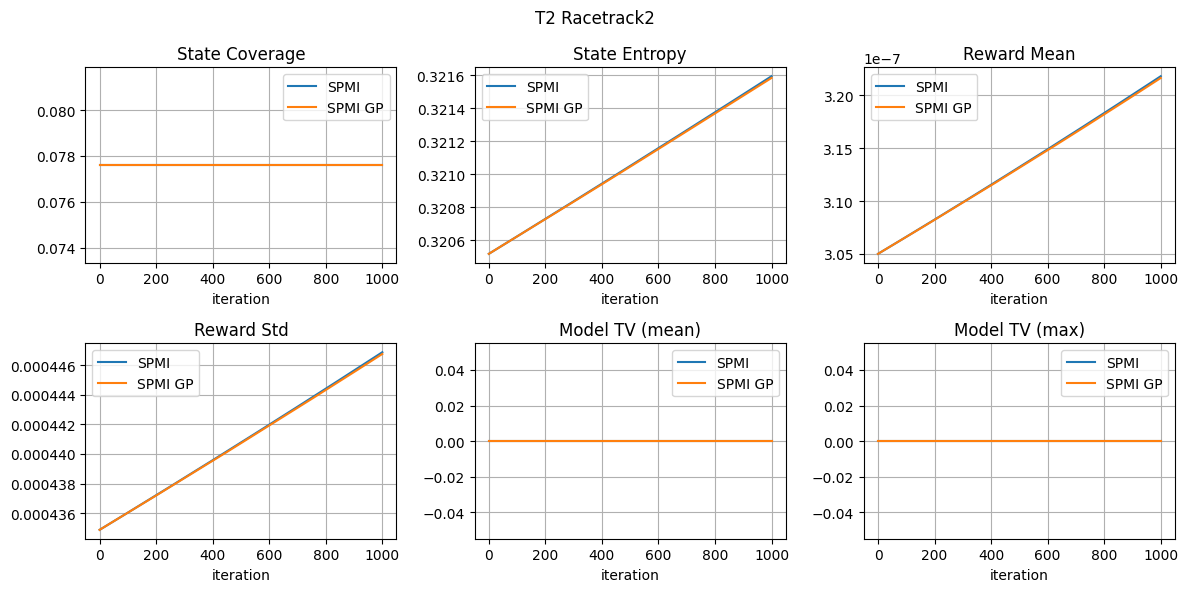

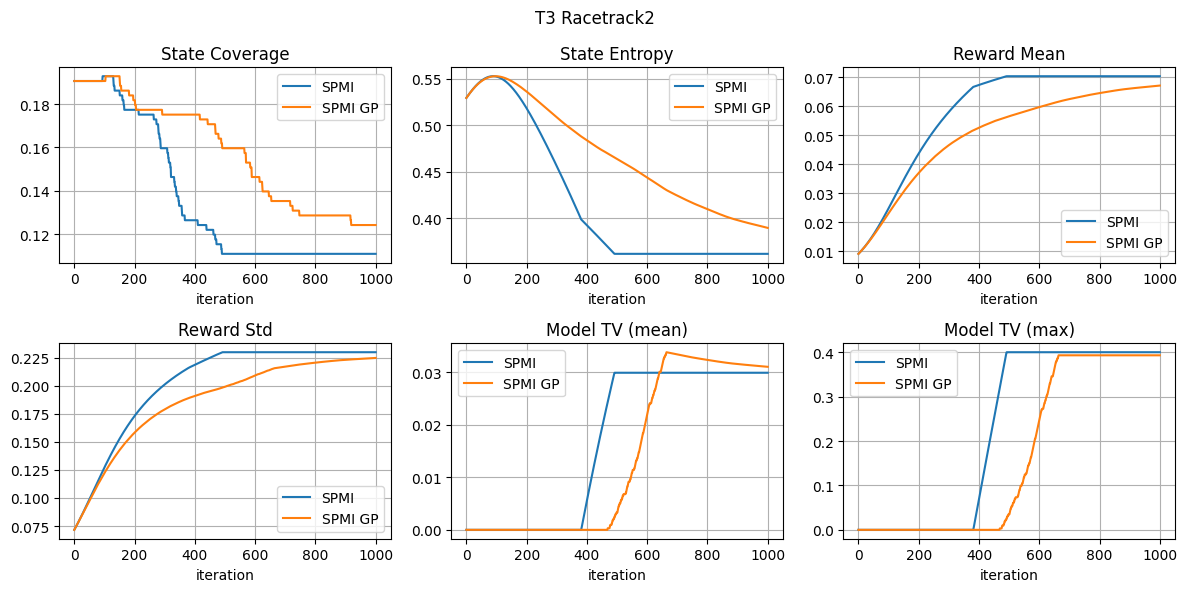

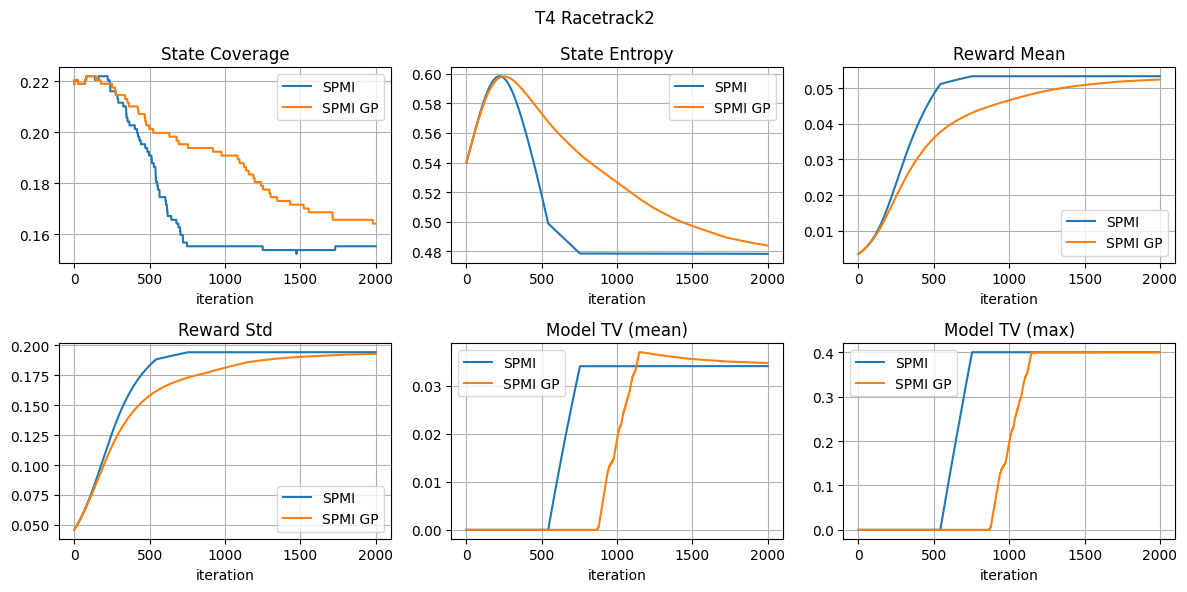

In [14]:
for track in ['T1', 'T2', 'T3', 'T4']:
    metric_files = {
        "SPMI": f"data/racetrack2_{track}/metrics_spmi.csv",
        "SPMI GP": f"data/racetrack2_gp_{track}/metrics_spmi.csv",
    }
    plot_metrics(metric_files, f"{track} Racetrack2")


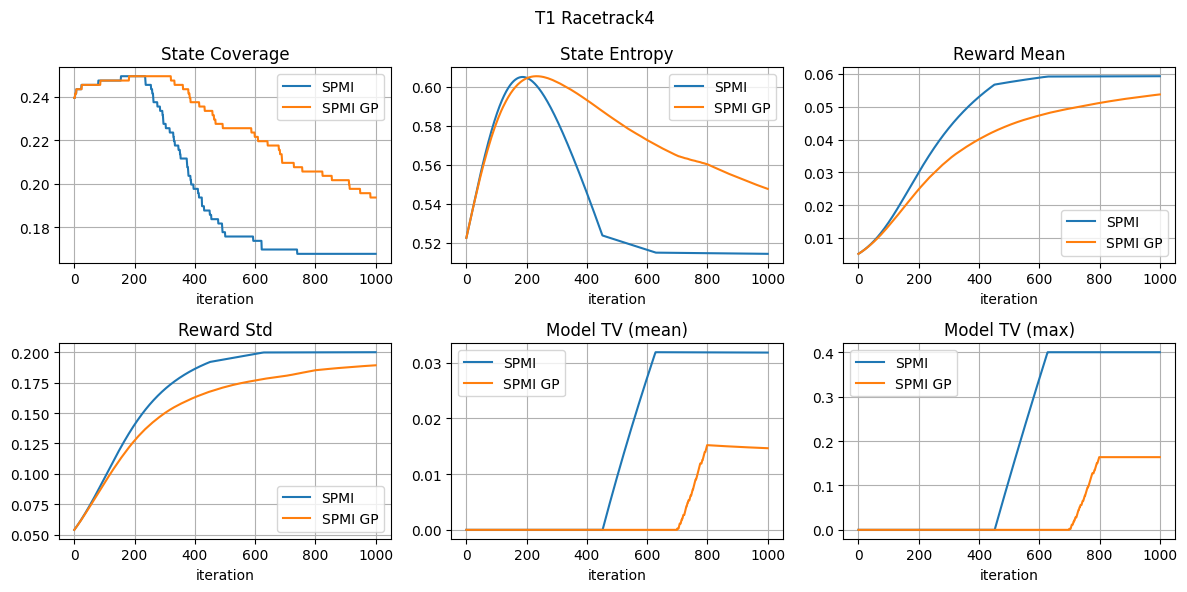

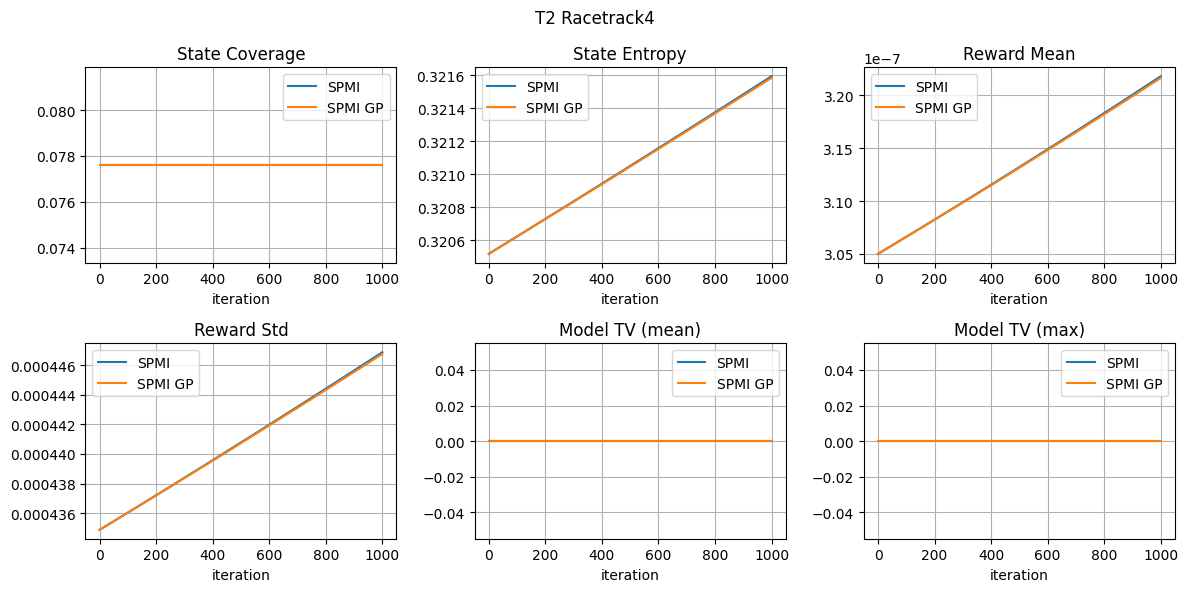

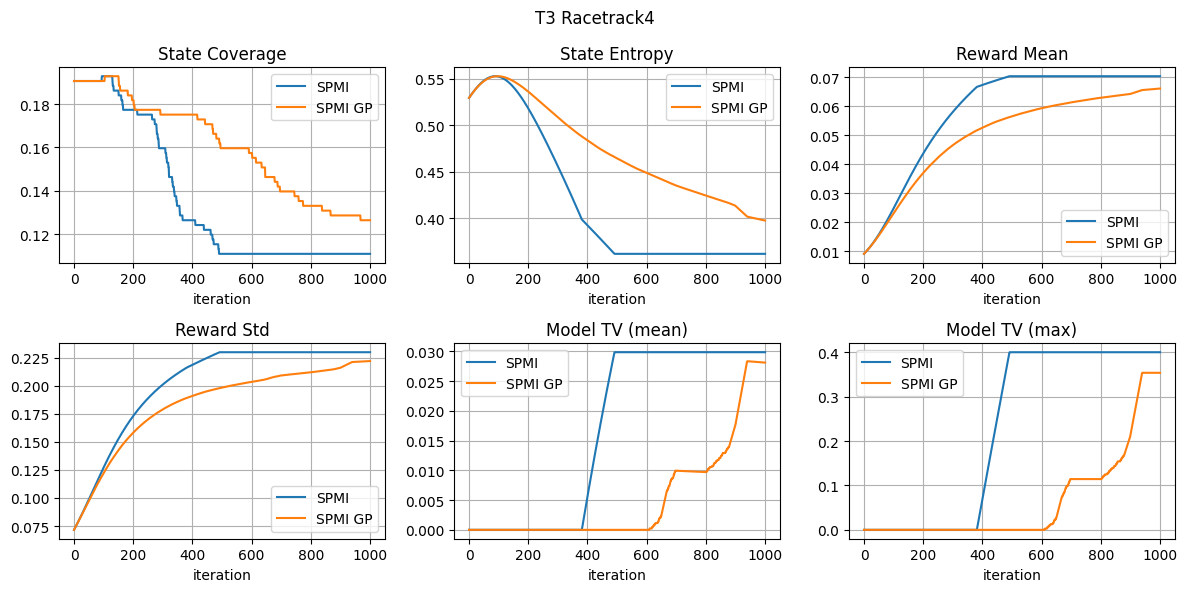

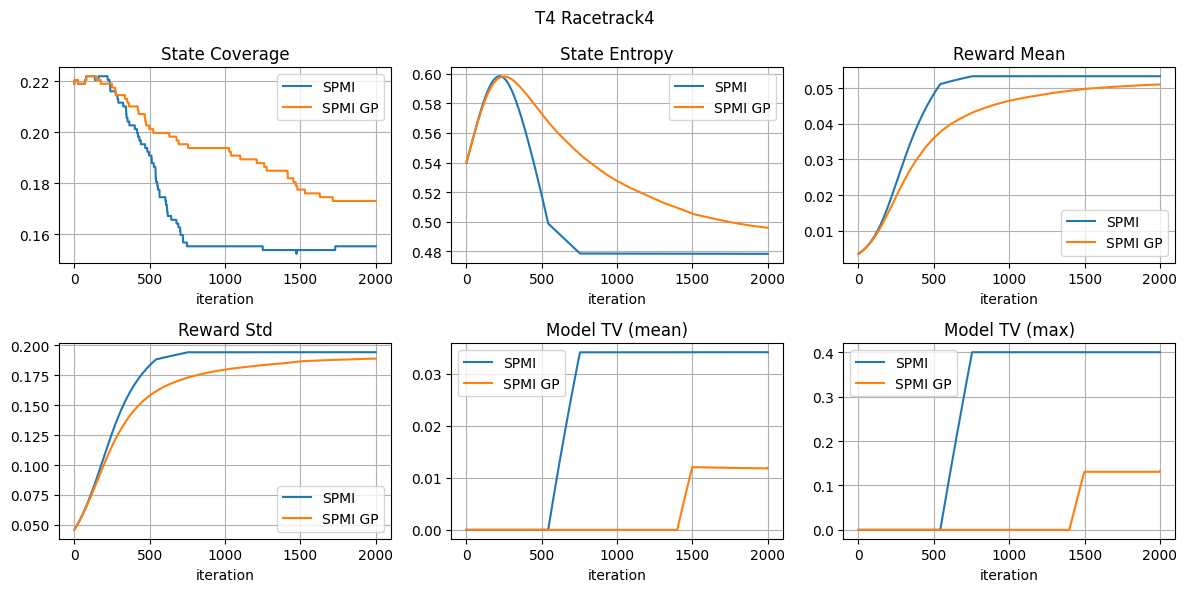

In [15]:
for track in ['T1', 'T2', 'T3', 'T4']:
    metric_files = {
        "SPMI": f"data/racetrack4_{track}/metrics_spmi.csv",
        "SPMI GP": f"data/racetrack4_gp_{track}/metrics_spmi.csv",
    }
    plot_metrics(metric_files, f"{track} Racetrack4")